In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split



## 1) Découverte des données

In [2]:
pth = os.path.abspath(os.path.join(os.getcwd(), ".."))
pth = os.path.abspath(os.path.join(pth, "data"))
print(pth)  # Affiche le répertoire parent

c:\Users\DF6610\Challenge_tech\data


In [3]:
# Lecture du fichier
df = pd.read_csv(pth + "/intent-detection-train.csv")
df.head()

,text,label
0,Pouvez-vous me dire comment dire «je ne parle ...,translate
1,Dites-moi comment dire: «C'est une belle matin...,translate
2,"Si j'étais japonais, comment dirais-je que je ...",translate
3,Comment dire «hôtel» en finnois,translate
4,"J'ai besoin que vous traduisiez la phrase, «no...",translate


In [4]:
print(df.shape[0]) # Affiche le nombre de lignes

75


In [5]:
# remarque : les données ne sont pas nombreuses

In [6]:
# Est-ce qu'il y a des valeurs manquantes ?
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [7]:
# Est ce qu'il ya des doublons de textes ? 
print(df['text'].duplicated().sum())

0


## 2) Distribution des labels 

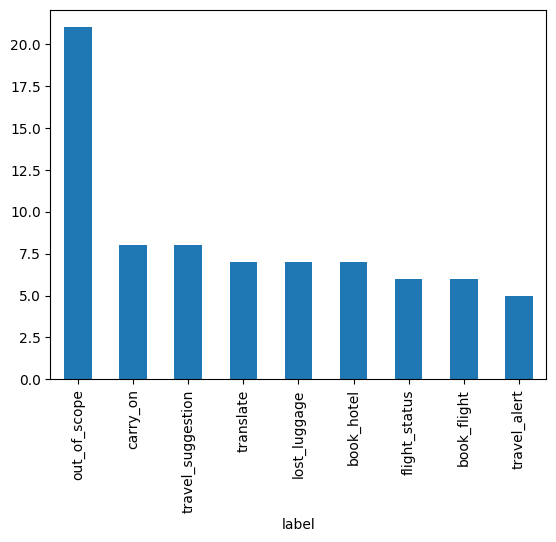

In [8]:
df.label.value_counts().plot(kind='bar')
plt.show()

In [9]:
print(df.label.value_counts())

label
out_of_scope         21
carry_on              8
travel_suggestion     8
translate             7
lost_luggage          7
book_hotel            7
flight_status         6
book_flight           6
travel_alert          5
Name: count, dtype: int64


In [10]:
# Il y a 9 classes différentes
# Les classes sont équilibrées sauf pour la classe 'out_of_scope' qui est sur-représentée, mais cela semble logique car elle regroupe tout ce qui n'est pas dans les autres classes

## 3) Séparation des données

In [24]:
# Split stratifié
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train_train, X_val, y_train_train, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

ValueError: The test_size = 6 should be greater or equal to the number of classes = 9

In [25]:
# vérifier que les classes sont bien réparties
print(y_train.value_counts(normalize=True))
print(y_train_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))



label
out_of_scope         0.283333
travel_suggestion    0.100000
lost_luggage         0.100000
translate            0.100000
carry_on             0.100000
flight_status        0.083333
book_flight          0.083333
book_hotel           0.083333
travel_alert         0.066667
Name: proportion, dtype: float64
label
out_of_scope         0.270833
translate            0.104167
lost_luggage         0.104167
carry_on             0.104167
travel_suggestion    0.104167
book_hotel           0.083333
book_flight          0.083333
flight_status        0.083333
travel_alert         0.062500
Name: proportion, dtype: float64
label
out_of_scope         0.333333
flight_status        0.083333
book_hotel           0.083333
lost_luggage         0.083333
translate            0.083333
travel_alert         0.083333
travel_suggestion    0.083333
book_flight          0.083333
carry_on             0.083333
Name: proportion, dtype: float64
label
out_of_scope         0.266667
book_hotel           0.133333
carry_o

In [26]:
# vérifier que chaque split contient bien tous les 9 labels

print(y_train.value_counts())
print(y_train_train.value_counts())
print(y_val.value_counts())
print(y_test.value_counts())

label
out_of_scope         17
travel_suggestion     6
lost_luggage          6
translate             6
carry_on              6
flight_status         5
book_flight           5
book_hotel            5
travel_alert          4
Name: count, dtype: int64
label
out_of_scope         13
translate             5
lost_luggage          5
carry_on              5
travel_suggestion     5
book_hotel            4
book_flight           4
flight_status         4
travel_alert          3
Name: count, dtype: int64
label
out_of_scope         4
flight_status        1
book_hotel           1
lost_luggage         1
translate            1
travel_alert         1
travel_suggestion    1
book_flight          1
carry_on             1
Name: count, dtype: int64
label
out_of_scope         4
book_hotel           2
carry_on             2
travel_suggestion    2
lost_luggage         1
travel_alert         1
book_flight          1
translate            1
flight_status        1
Name: count, dtype: int64


In [27]:
df_train_train = pd.concat([X_train_train, y_train_train], axis=1)
df_val = pd.concat([X_val, y_val], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

In [31]:
# Export
df_train_train.to_csv(pth + "/train-train.csv", index=False)
df_val.to_csv(pth + "/val.csv", index=False)
df_test.to_csv(pth + "/test.csv", index=False)